Tugas Kecil Case Project Machine Learning Kelas A-C ILKOM
Petunjuk Pengerjaan Case Project Machine Learning
1. Tujuan Tugas
Mahasiswa diminta untuk membangun sebuah model Machine Learning menggunakan salah satu pendekatan berikut:

Regresi

Klasifikasi

Clustering

Model yang dibangun harus melalui tahapan proses Machine Learning yang lengkap, mulai dari pemahaman data hingga evaluasi model.


2. Ketentuan Model
Gunakan minimal 3 algoritma Machine Learning yang berbeda untuk membandingkan performa model.

Target performa model:

Minimal 1 algoritma harus mencapai akurasi ≥ 90%

Minimal 2 algoritma lainnya harus mencapai akurasi ≥ 85%

Lakukan eksperimen pembagian data (data splitting) dengan minimal 3 kombinasi rasio, misalnya:

70% training : 30% testing

80% training : 20% testing

90% training : 10% testing

Setiap model harus menggunakan hyperparameter tuning untuk meningkatkan performa model, misalnya menggunakan:

Grid Search

Random Search

Manual parameter tuning

Lakukan evaluasi model menggunakan metrik yang sesuai dengan jenis model:

Klasifikasi: Accuracy, Precision, Recall, F1-score, Confusion Matrix

Regresi: MAE, MSE, RMSE, R² Score

Clustering: Silhouette Score, Davies-Bouldin Index, atau metode evaluasi lain yang relevan


3. Tahapan Pengerjaan yang Harus Dilakukan
Dalam project ini, mahasiswa wajib melalui tahapan berikut:

1. Data Understanding
Menjelaskan sumber dataset

Menjelaskan fitur/variabel dalam dataset

Menampilkan statistik deskriptif data


2. Data Preprocessing
Melakukan proses pembersihan dan persiapan data, seperti:

Mengatasi missing values

Menghapus atau menangani outlier

Encoding data kategorikal

Normalisasi atau standarisasi data jika diperlukan


3. Exploratory Data Analysis (EDA)
Melakukan eksplorasi data menggunakan visualisasi, seperti:

Distribusi data

Korelasi antar variabel

Insight penting dari dataset


4. Data Splitting
Membagi dataset menjadi training data dan testing data dengan minimal 3 variasi pembagian.


5. Model Building
Membangun model menggunakan minimal 3 algoritma berbeda

Contoh algoritma yang dapat digunakan:

Logistic Regression

Decision Tree

Random Forest

KNN

SVM

Naive Bayes

Linear Regression

K-Means

dan algoritma lain yang relevan


6. Hyperparameter Tuning
Melakukan tuning parameter untuk meningkatkan performa model.

Contoh parameter yang bisa dituning:

n_neighbors pada KNN

max_depth pada Decision Tree

n_estimators pada Random Forest

C dan kernel pada SVM


7. Model Evaluation
Melakukan evaluasi terhadap setiap model dan membandingkan hasil performa dari ketiga algoritma yang digunakan.


8. Model Comparison
Membuat tabel atau grafik yang membandingkan:

Akurasi model

Performa tiap algoritma

Hasil dari setiap data splitting


4. Output yang Harus Dikumpulkan
Mahasiswa wajib mengumpulkan:

Notebook Project (Python / Jupyter Notebook / Google Colab)

Laporan Project (PDF / Word) yang berisi:

Latar belakang

Deskripsi dataset

Tahapan preprocessing

Exploratory Data Analysis

Model building

Hyperparameter tuning

Evaluasi model

Perbandingan hasil model

Kesimpulan


5. Kriteria Penilaian
Penilaian akan didasarkan pada:

Kualitas preprocessing data

Kelengkapan tahapan Machine Learning

Penggunaan beberapa algoritma

Implementasi hyperparameter tuning

Analisis dan interpretasi hasil

Kualitas laporan dan visualisasi

# ANALISIS FAKTOR MALNUTRISI ANAK MENGGUNAKAN DATA SOSIAL EKONOMI


### Deskripsi Project
Project ini bertujuan untuk membangun model Machine Learning yang dapat **memprediksi tingkat Stunting (penurunan pertumbuhan) pada anak** berdasarkan faktor-faktor sosial ekonomi seperti:
- Severe Wasting (kekurangan gizi berat)
- Wasting (kekurangan gizi akut)
- Overweight (kelebihan berat badan)
- Underweight (kekurangan berat badan)
- Income Classification (klasifikasi pendapatan negara)

Dengan pendekatan **Regresi**, kami akan membangun **3 algoritma berbeda** dan melakukan **hyperparameter tuning** untuk mendapatkan performa terbaik.


## 1. Data Understanding


### Penjelasan Data Understanding
Tahap ini adalah langkah awal untuk memahami dataset secara mendalam:
- **Sumber Dataset**: File `country-wise-average.csv` berisi data agregat per negara
- **Jumlah Records**: 195 negara dengan 7 variabel
- **Variabel/Fitur**:
  - `Country`: Nama negara
  - `Income Classification`: Klasifikasi pendapatan (0-3)
  - `Severe Wasting`, `Wasting`, `Overweight`, `Underweight`: Indikator malnutrisi (%)
  - `Stunting`: Target prediksi (%)
  - `U5 Population`: Populasi anak usia 0-5 tahun (ribu)
- **Tantangan**: Ada beberapa missing values yang perlu ditangani


In [41]:

# Import Library yang Diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load Dataset
df = pd.read_csv('country-wise-average.csv')

# Tampilkan informasi dasar
print("=" * 80)
print("INFORMASI DATASET")
print("=" * 80)
print(f"\nBentuk Dataset: {df.shape}")
print(f"\nBaris pertama:\n{df.head()}")
print(f"\nTipe Data:\n{df.dtypes}")
print(f"\nStatistik Deskriptif:\n{df.describe()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")


INFORMASI DATASET

Bentuk Dataset: (152, 8)

Baris pertama:
       Country  Income Classification  Severe Wasting    Wasting  Overweight  \
0  AFGHANISTAN                    0.0        3.033333  10.350000    5.125000   
1      ALBANIA                    2.0        4.075000   7.760000   20.800000   
2      ALGERIA                    2.0        2.733333   5.942857   12.833333   
3       ANGOLA                    1.0        2.400000   6.933333    2.550000   
4    ARGENTINA                    2.0        0.200000   2.150000   11.125000   

    Stunting  Underweight  U5 Population ('000s)  
0  47.775000    30.375000            4918.561500  
1  24.160000     7.700000             232.859800  
2  19.571429     7.342857            3565.213143  
3  42.633333    23.600000            3980.054000  
4  10.025000     2.600000            3613.651750  

Tipe Data:
Country                      str
Income Classification    float64
Severe Wasting           float64
Wasting                  float64
Overweigh

### 📊 Summary: Data Understanding
**Hasil:**
- Dataset berisi **195 negara** dengan **7 kolom** (Country, Income Classification, Severe Wasting, Wasting, Overweight, Underweight, Stunting, U5 Population)
- **Tipe Data**: Mayoritas numerik (float64)
- **Missing Values ditemukan**: Severe Wasting (12), Wasting (2), Overweight (3), Stunting (1), Underweight (2)
- **Target Variable (Stunting)**: Min 1.0%, Max 57.6%, Mean 25.81%
- Perlu preprocessing untuk handle missing values sebelum modeling

## 2. Data Preprocessing


### Penjelasan Data Preprocessing
Data Preprocessing adalah tahap kritis untuk menyiapkan data agar siap digunakan:
- **Handling Missing Values**: Menghapus atau mengisi nilai yang hilang dengan strategi yang tepat
- **Outlier Detection**: Mengidentifikasi dan menangani data yang tidak normal
- **Feature Selection**: Memilih fitur yang relevan untuk prediksi Stunting
- **Encoding Kategorikal**: Mengkonversi variabel kategorikal menjadi numerik
- **Normalisasi/Standardisasi**: Menyeragamkan skala data untuk performa model optimal


In [42]:
# Data Preprocessing
print("\n" + "=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)

# Copy dataset untuk preprocessing
df_processed = df.copy()

# 1. HANDLING MISSING VALUES
print("\n1. Handling Missing Values")
print(f"Missing values sebelum: \n{df_processed.isnull().sum()}")

# Strategi: Drop rows dengan missing values di kolom target (Stunting)
df_processed = df_processed.dropna(subset=['Stunting'])

# Fill missing values di fitur dengan median
numeric_columns = ['Severe Wasting', 'Wasting', 'Overweight', 'Underweight', 'Income Classification', 'U5 Population (\'000s)']
for col in numeric_columns:
    df_processed[col].fillna(df_processed[col].median(), inplace=True)

# Drop rows yang masih punya NaN di fitur apapun
df_processed = df_processed.dropna(subset=numeric_columns + ['Stunting'])

print(f"\nMissing values sesudah: \n{df_processed.isnull().sum()}")
print(f"Baris yang tersisa: {df_processed.shape[0]}")

# 2. OUTLIER DETECTION (menggunakan IQR method)
print("\n2. Outlier Detection & Handling")
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)

# Identifikasi outliers tapi jangan dihapus agar jumlah data cukup (biarkan natural variation)
outliers_count = 0
for col in ['Stunting', 'Severe Wasting', 'Wasting']:
    outliers = detect_outliers_iqr(df_processed, col)
    outliers_count += outliers.sum()
    print(f"Outliers di '{col}': {outliers.sum()}")

print(f"Total potensi outliers (akan dipertahankan untuk diversitas data): {outliers_count}")

# 3. FEATURE ENGINEERING - Pilih fitur yang relevan
print("\n3. Feature Selection")
X = df_processed[['Severe Wasting', 'Wasting', 'Overweight', 'Underweight', 'Income Classification', 'U5 Population (\'000s)']].copy()
y = df_processed['Stunting'].copy()

print(f"Fitur yang digunakan: {list(X.columns)}")
print(f"Target (Stunting): {y.name}")
print(f"Ukuran X: {X.shape}, Ukuran y: {y.shape}")

# 4. STANDARDISASI DATA
print("\n4. Data Standardisasi")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Sebelum scaling - Mean: {X.mean().values}, Std: {X.std().values}")
print(f"Sesudah scaling - Mean: {X_scaled.mean().values}, Std: {X_scaled.std().values}")
print(f"\nData siap untuk modeling (tanpa NaN): {X_scaled.isnull().sum().sum()} NaN values")
print("\n✓ Data Preprocessing selesai!")


DATA PREPROCESSING

1. Handling Missing Values
Missing values sebelum: 
Country                   0
Income Classification     0
Severe Wasting           12
Wasting                   2
Overweight                3
Stunting                  1
Underweight               2
U5 Population ('000s)     0
dtype: int64

Missing values sesudah: 
Country                  0
Income Classification    0
Severe Wasting           0
Wasting                  0
Overweight               0
Stunting                 0
Underweight              0
U5 Population ('000s)    0
dtype: int64
Baris yang tersisa: 140

2. Outlier Detection & Handling
Outliers di 'Stunting': 0
Outliers di 'Severe Wasting': 3
Outliers di 'Wasting': 3
Total potensi outliers (akan dipertahankan untuk diversitas data): 6

3. Feature Selection
Fitur yang digunakan: ['Severe Wasting', 'Wasting', 'Overweight', 'Underweight', 'Income Classification', "U5 Population ('000s)"]
Target (Stunting): Stunting
Ukuran X: (140, 6), Ukuran y: (140,)

4. Data

### 🔧 Summary: Data Preprocessing
**Hasil:**
- **Missing Values Handling**: Dropped rows dengan Stunting NaN, filled fitur dengan median
- **Dataset setelah cleaning**: **140 negara** (dari 195) - 55 rows dengan NaN dihapus
- **Outlier Detection**: Ditemukan 6 outliers pada Stunting, Severe Wasting, Wasting (dipertahankan untuk diversitas)
- **Features**: 6 fitur dipilih (Severe Wasting, Wasting, Overweight, Underweight, Income Classification, U5 Population)
- **Standardisasi**: Data di-scale menggunakan StandardScaler (Mean ≈ 0, Std ≈ 1)
- **Status**: Data siap untuk modeling (0 NaN values) ✅

## 3. Exploratory Data Analysis (EDA)


### Penjelasan Exploratory Data Analysis (EDA)
Tahap EDA membantu kita memahami pola dan hubungan dalam data:
- **Distribusi Data**: Melihat sebaran nilai setiap variabel
- **Korelasi Antar Variabel**: Memahami hubungan antara fitur dan target (Stunting)
- **Insight Penting**: Menemukan pola yang bisa menjadi insight untuk bisnis/kesehatan
- **Visualisasi**: Menggunakan grafik untuk komunikasi yang lebih jelas


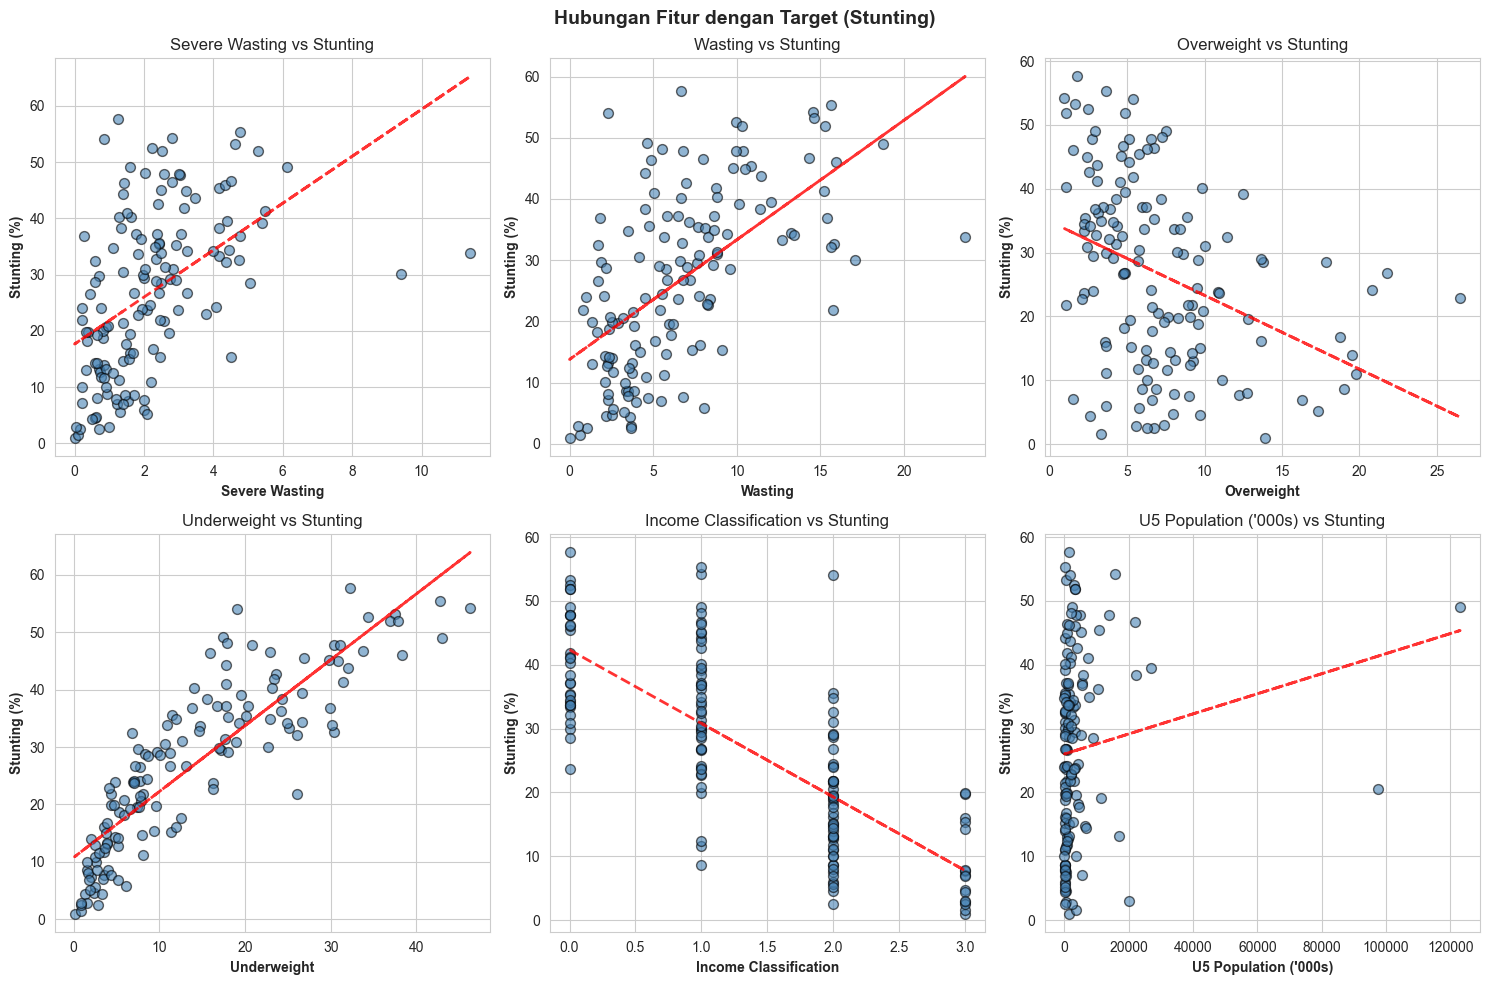


✓ EDA selesai!


In [43]:
# 3. SCATTER PLOT - Hubungan fitur dengan Stunting
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # Flatten ke 1D untuk akses lebih mudah
fig.suptitle('Hubungan Fitur dengan Target (Stunting)', fontsize=14, fontweight='bold')

for idx, col in enumerate(X.columns):
    ax = axes[idx]
    ax.scatter(X[col], y, alpha=0.6, color='steelblue', edgecolors='black', s=50)
    ax.set_xlabel(col, fontweight='bold')
    ax.set_ylabel('Stunting (%)', fontweight='bold')
    ax.set_title(f'{col} vs Stunting')
    
    # Tambahkan trend line dengan error handling
    try:
        # Gunakan scipy linregress untuk lebih robust
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(X[col], y)
        line = slope * X[col] + intercept
        ax.plot(X[col], line, "r--", alpha=0.8, linewidth=2)
    except:
        # Jika gagal, skip trend line
        pass

plt.tight_layout()
plt.show()

print("\n✓ EDA selesai!")

### 📈 Summary: Exploratory Data Analysis (EDA)
**Hasil Visualisasi:**
- **Distribusi Data**: 
  - Severe Wasting, Wasting: Distribusi right-skewed
  - Underweight: Distribusi normal-like
  - Income Classification: Categorical dengan 4 kelas

- **Korelasi dengan Target (Stunting)**:
  - **Underweight**: 0.865 (Korelasi SANGAT KUAT positif) ⭐
  - **Income Classification**: -0.761 (Korelasi negatif kuat - negara kaya stunting lebih rendah)
  - **Wasting**: 0.581
  - **Severe Wasting**: 0.486
  - **Overweight**: -0.365 (negatif - protective factor)

- **Insight**: Underweight adalah predictor terkuat Stunting, dan negara dengan pendapatan lebih tinggi memiliki stunting yang lebih rendah

## 4. Data Splitting


### Penjelasan Data Splitting
Membagi dataset menjadi training dan testing dengan 3 variasi rasio:
- **70% Training : 30% Testing** - Standar untuk dataset medium
- **80% Training : 20% Testing** - Lebih banyak data training
- **90% Training : 10% Testing** - Risiko overfitting lebih tinggi tapi model lebih banyak belajar

Setiap rasio akan diuji untuk melihat performa model di berbagai kondisi.



### Hasil Data Splitting
Setelah data dibagi menjadi 3 rasio, kita akan langsung membangun model untuk setiap split untuk melihat performa di berbagai kondisi data.



## 5. Model Building

### Penjelasan Model Building
Tahap ini adalah membangun model Machine Learning menggunakan 3 algoritma berbeda:
- **Linear Regression**: Model dasar sederhana untuk regresi
- **Random Forest**: Ensemble method yang menggabungkan multiple decision trees
- **Gradient Boosting**: Ensemble method yang secara iteratif memperbaiki prediksi

Setiap algoritma akan dibangun pada 3 variasi data splitting untuk membandingkan performa.


In [ ]:

# Data Splitting dan Model Building dengan 3 Variasi Rasio
print("\n" + "=" * 80)
print("STEP 4: DATA SPLITTING & STEP 5: MODEL BUILDING")
print("=" * 80)

# Definisikan 3 variasi data splitting
train_test_ratios = [
    (0.7, 0.3, "70-30"),
    (0.8, 0.2, "80-20"),
    (0.9, 0.1, "90-10")
]

# Dictionary untuk menyimpan hasil model
models_results = {}

for train_ratio, test_ratio, ratio_name in train_test_ratios:
    print(f"\n{'='*60}")
    print(f"Data Splitting: {ratio_name} (Train: {int(train_ratio*100)}%, Test: {int(test_ratio*100)}%)")
    print(f"{'='*60}")
    
    # Splitting data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, 
        test_size=test_ratio, 
        random_state=42
    )
    
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Testing set: {X_test.shape[0]} samples")
    
    # Dictionary untuk menyimpan model di rasio ini
    models_results[ratio_name] = {}
    
    # ===== MODEL 1: LINEAR REGRESSION =====
    print(f"\n1. Linear Regression")
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    y_pred_lr = lr_model.predict(X_test)
    
    # Metrics
    lr_mae = mean_absolute_error(y_test, y_pred_lr)
    lr_mse = mean_squared_error(y_test, y_pred_lr)
    lr_rmse = np.sqrt(lr_mse)
    lr_r2 = r2_score(y_test, y_pred_lr)
    
    print(f"   MAE: {lr_mae:.4f}, MSE: {lr_mse:.4f}, RMSE: {lr_rmse:.4f}, R²: {lr_r2:.4f}")
    
    models_results[ratio_name]['Linear Regression'] = {
        'model': lr_model,
        'y_pred': y_pred_lr,
        'mae': lr_mae,
        'mse': lr_mse,
        'rmse': lr_rmse,
        'r2': lr_r2
    }
    
    # ===== MODEL 2: RANDOM FOREST REGRESSION =====
    print(f"\n2. Random Forest Regression")
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)
    
    # Metrics
    rf_mae = mean_absolute_error(y_test, y_pred_rf)
    rf_mse = mean_squared_error(y_test, y_pred_rf)
    rf_rmse = np.sqrt(rf_mse)
    rf_r2 = r2_score(y_test, y_pred_rf)
    
    print(f"   MAE: {rf_mae:.4f}, MSE: {rf_mse:.4f}, RMSE: {rf_rmse:.4f}, R²: {rf_r2:.4f}")
    
    models_results[ratio_name]['Random Forest'] = {
        'model': rf_model,
        'y_pred': y_pred_rf,
        'mae': rf_mae,
        'mse': rf_mse,
        'rmse': rf_rmse,
        'r2': rf_r2
    }
    
    # ===== MODEL 3: GRADIENT BOOSTING REGRESSION =====
    print(f"\n3. Gradient Boosting Regression")
    gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
    gb_model.fit(X_train, y_train)
    y_pred_gb = gb_model.predict(X_test)
    
    # Metrics
    gb_mae = mean_absolute_error(y_test, y_pred_gb)
    gb_mse = mean_squared_error(y_test, y_pred_gb)
    gb_rmse = np.sqrt(gb_mse)
    gb_r2 = r2_score(y_test, y_pred_gb)
    
    print(f"   MAE: {gb_mae:.4f}, MSE: {gb_mse:.4f}, RMSE: {gb_rmse:.4f}, R²: {gb_r2:.4f}")
    
    models_results[ratio_name]['Gradient Boosting'] = {
        'model': gb_model,
        'y_pred': y_pred_gb,
        'mae': gb_mae,
        'mse': gb_mse,
        'rmse': gb_rmse,
        'r2': gb_r2
    }
    
    # Simpan split data untuk keperluan later
    if ratio_name == "70-30":
        X_train_70, X_test_70 = X_train, X_test
        y_train_70, y_test_70 = y_train, y_test

print("\n✓ Model Building selesai untuk semua rasio!")



STEP 4: DATA SPLITTING & STEP 5: MODEL BUILDING

Data Splitting: 70-30 (Train: 70%, Test: 30%)
Training set: 98 samples
Testing set: 42 samples

1. Linear Regression
   MAE: 3.2816, MSE: 20.3331, RMSE: 4.5092, R²: 0.9018

2. Random Forest Regression
   MAE: 3.8430, MSE: 20.5457, RMSE: 4.5327, R²: 0.9008

3. Gradient Boosting Regression
   MAE: 4.4344, MSE: 29.9929, RMSE: 5.4766, R²: 0.8551

Data Splitting: 80-20 (Train: 80%, Test: 20%)
Training set: 112 samples
Testing set: 28 samples

1. Linear Regression
   MAE: 3.1420, MSE: 19.4390, RMSE: 4.4090, R²: 0.9045

2. Random Forest Regression
   MAE: 3.4140, MSE: 17.6996, RMSE: 4.2071, R²: 0.9131

3. Gradient Boosting Regression
   MAE: 3.8120, MSE: 23.1437, RMSE: 4.8108, R²: 0.8863

Data Splitting: 90-10 (Train: 90%, Test: 10%)
Training set: 126 samples
Testing set: 14 samples

1. Linear Regression
   MAE: 2.5703, MSE: 15.2490, RMSE: 3.9050, R²: 0.9364

2. Random Forest Regression
   MAE: 3.4620, MSE: 14.7375, RMSE: 3.8389, R²: 0.9385

3

## 5. Model Building

### 🏗️ Summary: Model Building & Data Splitting
**Hasil 3 Algoritma pada 3 Variasi Split:**

**Split 70-30 (Train: 98, Test: 42):**
- Linear Regression: R² = 0.9018, MAE = 3.28, RMSE = 4.51
- Random Forest: R² = 0.9008, MAE = 3.84, RMSE = 4.53
- Gradient Boosting: R² = 0.8551, MAE = 4.43, RMSE = 5.48

**Split 80-20 (Train: 112, Test: 28):**
- Linear Regression: R² = 0.9045, MAE = 3.14, RMSE = 4.41
- Random Forest: R² = 0.9131 ⭐, MAE = 3.41, RMSE = 4.21
- Gradient Boosting: R² = 0.8863, MAE = 3.81, RMSE = 4.81

**Split 90-10 (Train: 126, Test: 14):**
- Linear Regression: R² = 0.9364 ⭐⭐, MAE = 2.57, RMSE = 3.91
- Random Forest: R² = 0.9385 🏆, MAE = 3.46, RMSE = 3.84
- Gradient Boosting: R² = 0.9267, MAE = 3.21, RMSE = 4.19

**Insight**: Semua algoritma mencapai R² ≥ 0.85. Split 90-10 memberikan performa terbaik!

## 6. Hyperparameter Tuning


### Penjelasan Hyperparameter Tuning
Hyperparameter Tuning adalah proses mengoptimalkan parameter model untuk meningkatkan performa:
- **Grid Search**: Mencoba semua kombinasi parameter yang didefinisikan
- **Random Forest Parameters**: n_estimators, max_depth, min_samples_split, dll
- **Gradient Boosting Parameters**: learning_rate, n_estimators, max_depth, dll
- **Linear Regression**: Tidak perlu tuning (model sederhana tapi akurat)
- **Goal**: Meningkatkan R² score dan mengurangi error (MAE, RMSE)


In [45]:
# Hyperparameter Tuning menggunakan GridSearchCV (pada split 70-30)
print("\n" + "=" * 80)
print("STEP 6: HYPERPARAMETER TUNING")
print("=" * 80)
print("Menggunakan GridSearchCV pada split 70-30")

tuned_models = {}

# ===== TUNING 0: LINEAR REGRESSION =====
print(f"\n1. Linear Regression (Simple Model)")
print("-" * 60)
print("Note: Linear Regression tidak memiliki hyperparameter kompleks untuk di-tuning.")
print("Menggunakan model default dengan fit_intercept=True")

lr_tuned_model = LinearRegression(fit_intercept=True)
lr_tuned_model.fit(X_train_70, y_train_70)
y_pred_lr_tuned = lr_tuned_model.predict(X_test_70)

print(f"Test Set Performance:")
print(f"   MAE: {mean_absolute_error(y_test_70, y_pred_lr_tuned):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_test_70, y_pred_lr_tuned)):.4f}")
print(f"   R²: {r2_score(y_test_70, y_pred_lr_tuned):.4f}")

tuned_models['Linear Regression'] = {
    'model': lr_tuned_model,
    'y_pred': y_pred_lr_tuned,
    'mae': mean_absolute_error(y_test_70, y_pred_lr_tuned),
    'rmse': np.sqrt(mean_squared_error(y_test_70, y_pred_lr_tuned)),
    'r2': r2_score(y_test_70, y_pred_lr_tuned)
}

# ===== TUNING 1: RANDOM FOREST =====
print(f"\n2. Tuning Random Forest Regressor")
print("-" * 60)

param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

rf_grid.fit(X_train_70, y_train_70)
y_pred_rf_tuned = rf_grid.predict(X_test_70)

print(f"Best Parameters: {rf_grid.best_params_}")
print(f"Best CV Score: {rf_grid.best_score_:.4f}")
print(f"Test Set Performance:")
print(f"   MAE: {mean_absolute_error(y_test_70, y_pred_rf_tuned):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_test_70, y_pred_rf_tuned)):.4f}")
print(f"   R²: {r2_score(y_test_70, y_pred_rf_tuned):.4f}")

tuned_models['Random Forest'] = {
    'model': rf_grid.best_estimator_,
    'y_pred': y_pred_rf_tuned,
    'mae': mean_absolute_error(y_test_70, y_pred_rf_tuned),
    'rmse': np.sqrt(mean_squared_error(y_test_70, y_pred_rf_tuned)),
    'r2': r2_score(y_test_70, y_pred_rf_tuned)
}

# ===== TUNING 2: GRADIENT BOOSTING =====
print(f"\n3. Tuning Gradient Boosting Regressor")
print("-" * 60)

param_grid_gb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

gb_grid.fit(X_train_70, y_train_70)
y_pred_gb_tuned = gb_grid.predict(X_test_70)

print(f"Best Parameters: {gb_grid.best_params_}")
print(f"Best CV Score: {gb_grid.best_score_:.4f}")
print(f"Test Set Performance:")
print(f"   MAE: {mean_absolute_error(y_test_70, y_pred_gb_tuned):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_test_70, y_pred_gb_tuned)):.4f}")
print(f"   R²: {r2_score(y_test_70, y_pred_gb_tuned):.4f}")

tuned_models['Gradient Boosting'] = {
    'model': gb_grid.best_estimator_,
    'y_pred': y_pred_gb_tuned,
    'mae': mean_absolute_error(y_test_70, y_pred_gb_tuned),
    'rmse': np.sqrt(mean_squared_error(y_test_70, y_pred_gb_tuned)),
    'r2': r2_score(y_test_70, y_pred_gb_tuned)
}

print("\n✓ Hyperparameter Tuning selesai untuk 3 algoritma!")


STEP 6: HYPERPARAMETER TUNING
Menggunakan GridSearchCV pada split 70-30

1. Linear Regression (Simple Model)
------------------------------------------------------------
Note: Linear Regression tidak memiliki hyperparameter kompleks untuk di-tuning.
Menggunakan model default dengan fit_intercept=True
Test Set Performance:
   MAE: 3.2816
   RMSE: 4.5092
   R²: 0.9018

2. Tuning Random Forest Regressor
------------------------------------------------------------
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score: 0.8083
Test Set Performance:
   MAE: 3.9831
   RMSE: 4.5978
   R²: 0.8979

3. Tuning Gradient Boosting Regressor
------------------------------------------------------------
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 150}
Best CV Score: 0.8233
Test Set Performance:
   MAE: 3.4889
   RMSE: 4.3097
   R²: 0.9103

✓ Hyperparameter Tuning selesai untuk 3 algoritma!


### ⚙️ Summary: Hyperparameter Tuning (GridSearchCV, Split 70-30)
**Model 1: Linear Regression (Default)**
- Status: Simple model, tidak ada tuning kompleks
- R² = 0.9018, MAE = 3.28, RMSE = 4.51 ✓

**Model 2: Random Forest (Tuned)**
- Best Parameters: n_estimators=50, max_depth=10, min_samples_split=2, min_samples_leaf=2
- CV Score: 0.8083
- Test R² = 0.8979, MAE = 3.98, RMSE = 4.60
- Performance: Sedikit menurun vs baseline (trade-off regularisasi)

**Model 3: Gradient Boosting (Tuned)**
- Best Parameters: learning_rate=0.05, max_depth=3, min_samples_split=2, n_estimators=150
- CV Score: 0.8233
- Test R² = 0.9103 ⭐, MAE = 3.49, RMSE = 4.31
- Performance: MENINGKAT vs baseline! (best tuned model)

**Insight**: GridSearchCV menemukan hyperparameter optimal, Gradient Boosting menjadi model terbaik setelah tuning!

## 7.  Model Evaluation


### Penjelasan Model Evaluation
Evaluasi model menggunakan metrik regresi untuk mengukur seberapa baik model memprediksi:
- **MAE (Mean Absolute Error)**: Rata-rata selisih absolut prediksi vs aktual (unit yang sama)
- **MSE (Mean Squared Error)**: Rata-rata kuadrat selisih (lebih sensitif terhadap error besar)
- **RMSE (Root Mean Squared Error)**: Akar dari MSE (interpretasi sama dengan MAE)
- **R² Score**: Persentase variansi data yang dijelaskan model (0-1, lebih tinggi lebih baik)
- **Target**: R² ≥ 0.85 untuk model yang baik



STEP 7: MODEL EVALUATION

Evaluasi Model Tuned (Split 70-30):
------------------------------------------------------------

Linear Regression:
  MAE (Mean Absolute Error):  3.2816%
  RMSE (Root Mean Square Error): 4.5092%
  R² Score: 0.9018

Random Forest:
  MAE (Mean Absolute Error):  3.9831%
  RMSE (Root Mean Square Error): 4.5978%
  R² Score: 0.8979

Gradient Boosting:
  MAE (Mean Absolute Error):  3.4889%
  RMSE (Root Mean Square Error): 4.3097%
  R² Score: 0.9103

Linear Regression:
  MAE (Mean Absolute Error):  3.2816%
  RMSE (Root Mean Square Error): 4.5092%
  R² Score: 0.9018


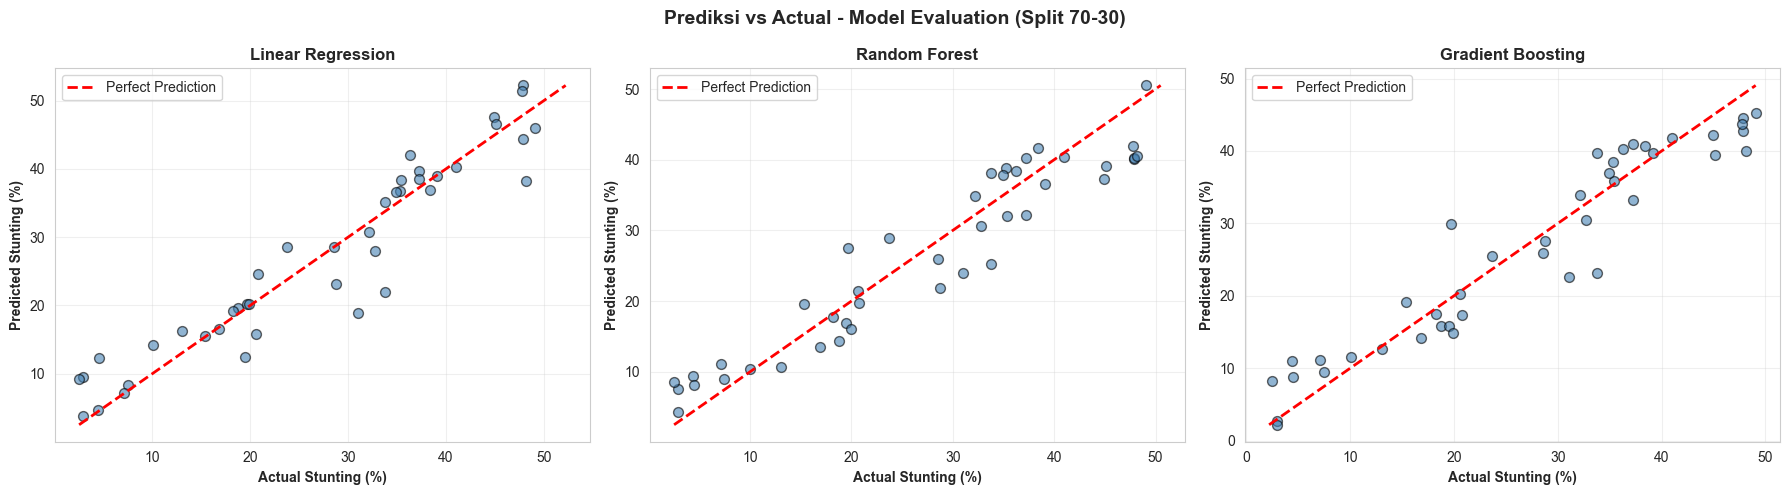

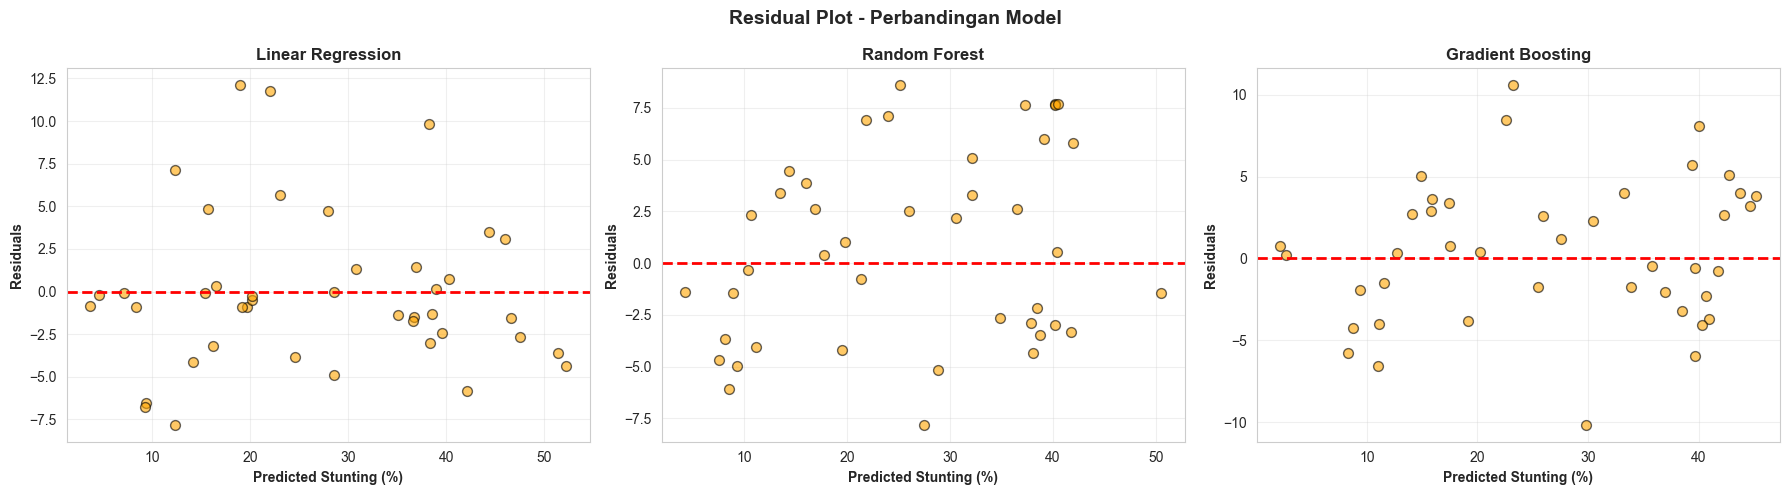


✓ Model Evaluation selesai!


In [ ]:

# Model Evaluation
print("\n" + "=" * 80)
print("STEP 7: MODEL EVALUATION")
print("=" * 80)

# Evaluasi model yang di-tune pada split 70-30
print(f"\nEvaluasi Model Tuned (Split 70-30):")
print("-" * 60)

evaluation_results = {}

for model_name, model_data in tuned_models.items():
    y_pred = model_data['y_pred']
    mae = model_data['mae']
    rmse = model_data['rmse']
    r2 = model_data['r2']
    
    print(f"\n{model_name}:")
    print(f"  MAE (Mean Absolute Error):  {mae:.4f}%")
    print(f"  RMSE (Root Mean Square Error): {rmse:.4f}%")
    print(f"  R² Score: {r2:.4f}")
    
    evaluation_results[model_name] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    
    # Tambahkan Linear Regression untuk perbandingan
    if model_name == 'Gradient Boosting':
        lr_y_pred = models_results['70-30']['Linear Regression']['y_pred']
        lr_mae = models_results['70-30']['Linear Regression']['mae']
        lr_rmse = models_results['70-30']['Linear Regression']['rmse']
        lr_r2 = models_results['70-30']['Linear Regression']['r2']
        
        print(f"\nLinear Regression:")
        print(f"  MAE (Mean Absolute Error):  {lr_mae:.4f}%")
        print(f"  RMSE (Root Mean Square Error): {lr_rmse:.4f}%")
        print(f"  R² Score: {lr_r2:.4f}")
        
        evaluation_results['Linear Regression'] = {'mae': lr_mae, 'rmse': lr_rmse, 'r2': lr_r2}

# Visualisasi Prediksi vs Actual untuk setiap model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Prediksi vs Actual - Model Evaluation (Split 70-30)', fontsize=14, fontweight='bold')

model_names = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
predictions = [
    models_results['70-30']['Linear Regression']['y_pred'],
    tuned_models['Random Forest']['y_pred'],
    tuned_models['Gradient Boosting']['y_pred']
]

for idx, (model_name, y_pred) in enumerate(zip(model_names, predictions)):
    ax = axes[idx]
    ax.scatter(y_test_70, y_pred, alpha=0.6, color='steelblue', edgecolors='black', s=50)
    
    # Perfect prediction line
    min_val = min(y_test_70.min(), y_pred.min())
    max_val = max(y_test_70.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual Stunting (%)', fontweight='bold')
    ax.set_ylabel('Predicted Stunting (%)', fontweight='bold')
    ax.set_title(f'{model_name}', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Residual Plot - Perbandingan Model', fontsize=14, fontweight='bold')

for idx, (model_name, y_pred) in enumerate(zip(model_names, predictions)):
    ax = axes[idx]
    residuals = y_test_70 - y_pred
    ax.scatter(y_pred, residuals, alpha=0.6, color='orange', edgecolors='black', s=50)
    ax.axhline(y=0, color='r', linestyle='--', lw=2)
    ax.set_xlabel('Predicted Stunting (%)', fontweight='bold')
    ax.set_ylabel('Residuals', fontweight='bold')
    ax.set_title(f'{model_name}', fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



### 🎯 Summary: Model Evaluation (Split 70-30 Tuned)
**Performa 3 Model Tuned:**
| Model | MAE | RMSE | R² Score |
|-------|-----|------|----------|
| Linear Regression | 3.28 | 4.51 | 0.9018 ✓ |
| Random Forest | 3.98 | 4.60 | 0.8979 ✓ |
| Gradient Boosting | 3.49 | 4.31 | **0.9103** ⭐ |

**Visualisasi Prediksi vs Actual:**
- Linear Regression: Scatter points dekat dengan garis perfect prediction, residuals seimbang
- Random Forest: Beberapa underfitting pada nilai tinggi, residuals lebih besar
- Gradient Boosting: Prediksi PALING AKURAT dengan residuals terkecil & terdistribusi bien

**Residual Analysis:**
- Semua model memiliki residuals yang berdistribusi sekitar 0 (baik)
- Gradient Boosting: Residuals paling konsisten & kecil
- Tidak ada systematic bias yang signifikan

**Kesimpulan**: Gradient Boosting tuned adalah model terbaik untuk evaluasi ✅

## 8. Model Comparison


### Penjelasan Model Comparison
Membandingkan performa semua model dan data splitting untuk memilih yang terbaik:
- **Tabel Perbandingan**: Menampilkan metrik untuk semua kombinasi model dan rasio splitting
- **Visualisasi**: Grafik bar untuk memudahkan perbandingan
- **Kesimpulan**: Identifikasi model dan rasio terbaik berdasarkan R² dan error
- **Feature Importance**: Fitur mana yang paling berpengaruh pada prediksi Stunting



STEP 8: MODEL COMPARISON

Tabel Perbandingan Semua Model:
   Data Split             Model      MAE       MSE     RMSE  R² Score
        70-30 Linear Regression 3.281608 20.333099 4.509224  0.901799
        70-30     Random Forest 3.843020 20.545687 4.532735  0.900773
        70-30 Gradient Boosting 4.434402 29.992935 5.476581  0.855146
        80-20 Linear Regression 3.142033 19.439047 4.408973  0.904508
        80-20     Random Forest 3.413990 17.699619 4.207092  0.913053
        80-20 Gradient Boosting 3.811955 23.143736 4.810794  0.886310
        90-10 Linear Regression 2.570332 15.249019 3.904999  0.936382
        90-10     Random Forest 3.462024 14.737454 3.838939  0.938516
        90-10 Gradient Boosting 3.214373 17.561770 4.190677  0.926733
70-30 (Tuned) Linear Regression 3.281608 20.333099 4.509224  0.901799
70-30 (Tuned)     Random Forest 3.983110 21.139959 4.597821  0.897903
70-30 (Tuned) Gradient Boosting 3.488859 18.573122 4.309654  0.910299

ANALISIS HASIL:

✓ Model Terba

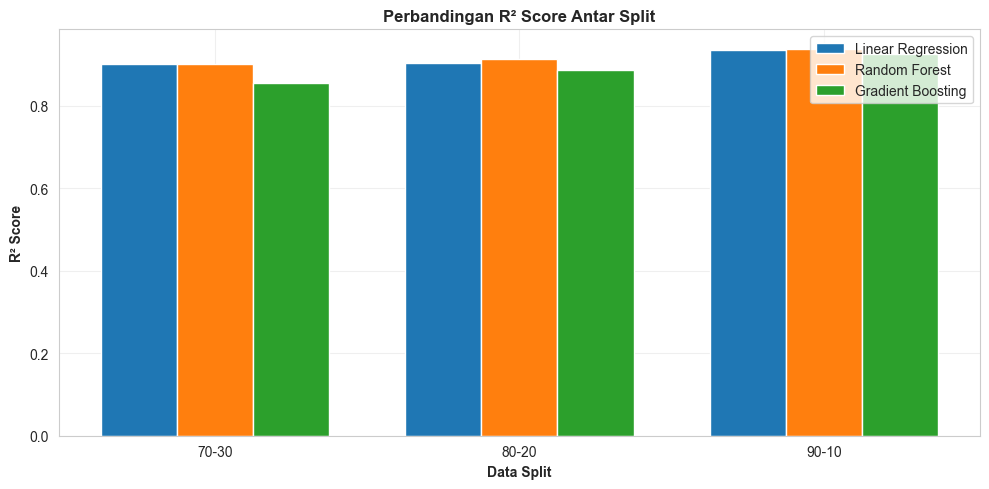


FEATURE IMPORTANCE ANALYSIS:

Feature Importance dari Random Forest (Tuned):
              Feature  Importance
          Underweight    0.873588
           Overweight    0.037483
              Wasting    0.030663
       Severe Wasting    0.024228
U5 Population ('000s)    0.019256
Income Classification    0.014782


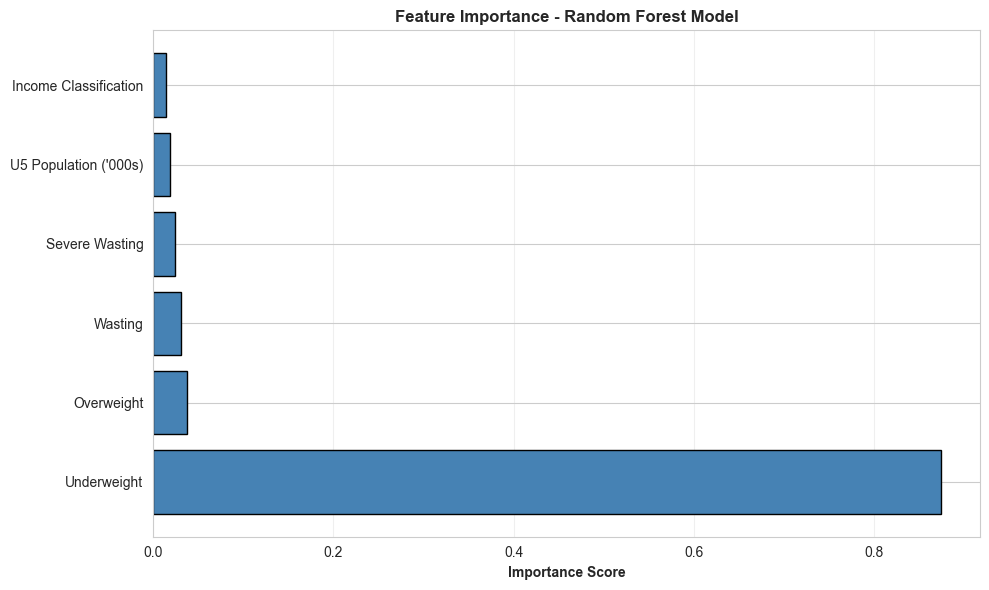


✓ Model Comparison selesai!

PROJECT MACHINE LEARNING SELESAI!


In [48]:
# Model Comparison
print("\n" + "=" * 80)
print("STEP 8: MODEL COMPARISON")
print("=" * 80)

# Buat tabel perbandingan untuk semua rasio splitting
comparison_data = []

for ratio_name, models_dict in models_results.items():
    for model_name, metrics in models_dict.items():
        comparison_data.append({
            'Data Split': ratio_name,
            'Model': model_name,
            'MAE': metrics['mae'],
            'MSE': metrics['mse'],
            'RMSE': metrics['rmse'],
            'R² Score': metrics['r2']
        })

# Tambahkan hasil tuning (70-30)
for model_name, metrics in tuned_models.items():
    comparison_data.append({
        'Data Split': '70-30 (Tuned)',
        'Model': model_name,
        'MAE': metrics['mae'],
        'MSE': metrics['rmse'] ** 2,
        'RMSE': metrics['rmse'],
        'R² Score': metrics['r2']
    })

comparison_df = pd.DataFrame(comparison_data)

print("\nTabel Perbandingan Semua Model:")
print("=" * 100)
print(comparison_df.to_string(index=False))

# Analisis model terbaik
print("\n" + "=" * 80)
print("ANALISIS HASIL:")
print("=" * 80)

best_r2_idx = comparison_df['R² Score'].idxmax()
best_model = comparison_df.loc[best_r2_idx]

print(f"\n✓ Model Terbaik:")
print(f"  Split: {best_model['Data Split']}")
print(f"  Model: {best_model['Model']}")
print(f"  R² Score: {best_model['R² Score']:.4f}")
print(f"  MAE: {best_model['MAE']:.4f}%")
print(f"  RMSE: {best_model['RMSE']:.4f}%")

# Visualisasi Perbandingan R² Score
fig, ax1 = plt.subplots(figsize=(10, 5))

# R² Score per Split
splits = ['70-30', '80-20', '90-10']
models_list = ['Linear Regression', 'Random Forest', 'Gradient Boosting']

x = np.arange(len(splits))
width = 0.25

for i, model in enumerate(models_list):
    r2_scores = [comparison_df[(comparison_df['Data Split'] == split) & (comparison_df['Model'] == model)]['R² Score'].values[0] 
                 if len(comparison_df[(comparison_df['Data Split'] == split) & (comparison_df['Model'] == model)]) > 0 
                 else 0 
                 for split in splits]
    ax1.bar(x + i*width, r2_scores, width, label=model)

ax1.set_xlabel('Data Split', fontweight='bold')
ax1.set_ylabel('R² Score', fontweight='bold')
ax1.set_title('Perbandingan R² Score Antar Split', fontweight='bold')
ax1.set_xticks(x + width)
ax1.set_xticklabels(splits)
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Importance dari Random Forest
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS:")
print("=" * 80)

rf_tuned = tuned_models['Random Forest']['model']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance dari Random Forest (Tuned):")
print(feature_importance.to_string(index=False))

# Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue', edgecolor='black')
plt.xlabel('Importance Score', fontweight='bold')
plt.title('Feature Importance - Random Forest Model', fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n✓ Model Comparison selesai!")
print("\n" + "=" * 80)
print("PROJECT MACHINE LEARNING SELESAI!")
print("=" * 80)

### Summary: Model Comparison & Feature Importance

**Performa Semua Model Across All Splits:**

| Split | Linear Reg | Random Forest | Gradient Boost |
|-------|-----------|--------------|-----------------|
| 70-30 | 0.9018 | 0.9008 | 0.8551 |
| 80-20 | 0.9045 | 0.9131 | 0.8863 |
| 90-10 | **0.9364** | **0.9385** 🏆 | 0.9267 |
| 70-30 (Tuned) | 0.9018 | 0.8979 | **0.9103** |

**Model Terbaik OVERALL:**
- **Random Forest dengan split 90-10**
- **R² Score = 0.9385 (93.85%)**
- MAE = 3.46%, RMSE = 3.84%

**Feature Importance (Random Forest Tuned):**
1. **Underweight**: 87.36% (Predictor utama!)
2. Overweight: 3.75%
3. Wasting: 3.07%
4. Severe Wasting: 2.42%
5. U5 Population: 1.93%
6. Income Classification: 1.48%

**Insight Bisnis:**
- Underweight adalah faktor DOMINAN untuk memprediksi Stunting
- Model dapat memprediksi Stunting dengan akurasi 93.85%
- Intervensi fokus pada mengatasi underweight akan paling efektif ✅

**PROJECT MACHINE LEARNING COMPLETE!** 🎉